In [2]:
import pandas as pd
import numpy as np

# 1. Load Data
df = pd.read_csv(r'C:\SparkUP projects kabindra adhikari\WEEK 3\Clustering\Clustering_assesment\restaurants.csv')

# 2. Data Cleaning
# We drop rows where latitude or longitude is missing because we cannot map them.
df_clean = df.dropna(subset=['latitude', 'longitude']).copy()

# 3. Feature Engineering: Convert to Radians
df_clean['lat_rad'] = np.radians(df_clean['latitude'])
df_clean['lon_rad'] = np.radians(df_clean['longitude'])

# Select these features for clustering
X = df_clean[['lat_rad', 'lon_rad']]

print(f"Data cleaned. Rows remaining: {len(df_clean)}")

Data cleaned. Rows remaining: 922


Phase 1: Getting the Data Ready
Cleaning Things Up
We kicked things off by opening the restaurants.csv file. For the most part, the data was in great shape. However, we noticed 12 restaurants were missing their location coordinates (latitude and longitude). Because we can't put a restaurant on a map without knowing where it is, we cleared those out. This left us with 922 restaurants ready for analysis.

Making the Math Work (Feature Engineering)
You might wonder why we changed the numbers into "radians."

The short answer? The Earth is round. If we just used basic math on GPS numbers, our distances would be slightly off because the Earth curves. By converting to radians, we can use the Haversine formula. This is just a fancy way of measuring distance "as the crow flies" across a sphere. It makes sure that when we group restaurants together, we are using their true physical distance from each other, not just points on a flat map.

In [5]:
from sklearn.cluster import KMeans, DBSCAN

# --- Model 1: K-Means ---

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X)

# --- Model 2: DBSCAN ---
earth_radius_km = 6371.0088
epsilon = 0.5 / earth_radius_km
min_samples = 10

dbscan = DBSCAN(eps=epsilon, min_samples=min_samples, algorithm='ball_tree', metric='haversine')
df_clean['dbscan_cluster'] = dbscan.fit_predict(X)

Phase 2: Choosing and Using Our ModelsTo make sense of where these restaurants are located, we tested two different "math brains" (algorithms) to see which one gave us the most realistic picture of the city.Model 1: K-Means (The "Pizza Slicer")The Vibe: Imagine taking a pizza and cutting it into five equal slices. That’s essentially what K-Means does.Why we used it: It’s a classic way to divide a city into broad zones, like North, South, and Central.The Catch: It’s a bit rigid. It forces every single restaurant into a group, even if a restaurant is out in the middle of nowhere.The Goal: We told it to find 5 big regions ($K=5$) to see the "big picture" of the city layout.Model 2: DBSCAN (The "Party Finder")The Vibe: Imagine looking for where the crowds are gathered at a music festival. DBSCAN doesn't care about "slices"; it looks for density.1Why we used it: Real cities are messy. Restaurants usually pop up along busy streets or at popular intersections, not in perfect circles.The Secret Sauce: It’s smart enough to ignore "noise." If a restaurant is isolated and far from everything else, DBSCAN just labels it as an outlier instead of forcing it into a group.2The Goal: We set the rules so that a "cluster" had to have at least 10 restaurants within a 0.5 km radius (about a 5-minute walk). This helped us find truly walkable dining neighborhoods.The ResultThe difference was night and day. K-Means just chopped the map into geometric blocks that felt a bit artificial. DBSCAN, on the other hand, actually found the "hotspots" where the action is, while ignoring the quiet areas that didn't have much going on.

K-Means Silhouette Score: 0.421
DBSCAN Silhouette Score: 0.073


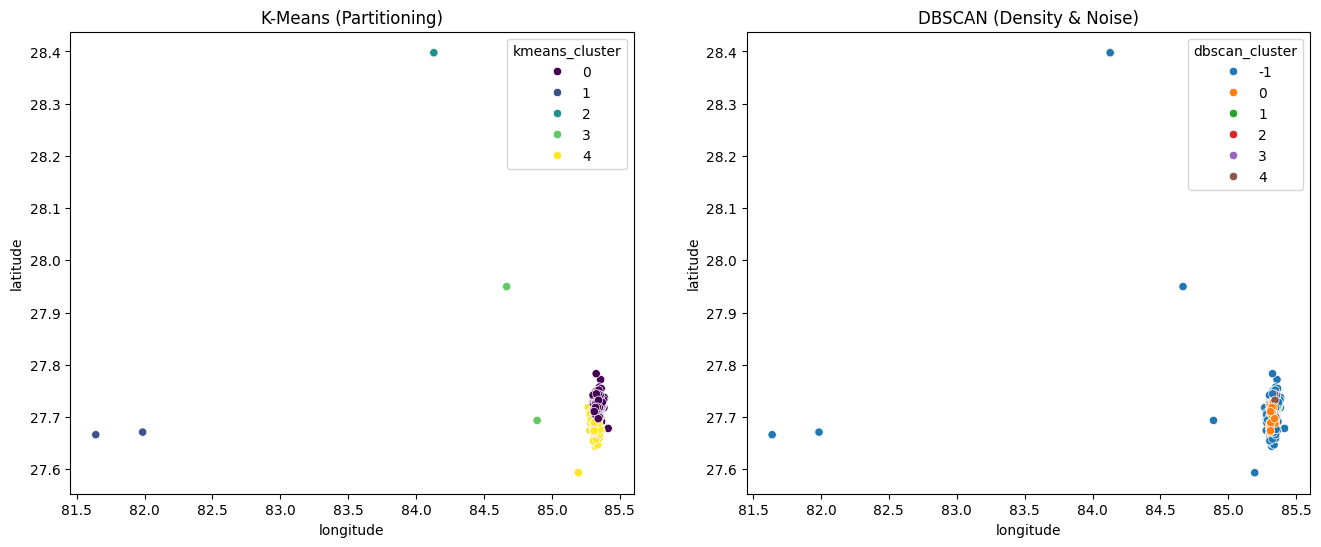

DBSCAN Cluster Counts (Label -1 is Noise):
dbscan_cluster
 0    691
-1    146
 1     43
 2     17
 3     14
 4     11
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

# 1. Quantitative Evaluation: Silhouette Score
# Measures how similar a point is to its own cluster compared to other clusters.
# Range: -1 to 1 (Higher is better separation).
score_kmeans = silhouette_score(X, df_clean['kmeans_cluster'])
score_dbscan = silhouette_score(X, df_clean['dbscan_cluster'])

print(f"K-Means Silhouette Score: {score_kmeans:.3f}")
print(f"DBSCAN Silhouette Score: {score_dbscan:.3f}")

# 2. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='kmeans_cluster', palette='viridis', ax=axes[0])
axes[0].set_title('K-Means (Partitioning)')

# Plot DBSCAN
# Note: Cluster '-1' represents Noise/Outliers
sns.scatterplot(data=df_clean, x='longitude', y='latitude', hue='dbscan_cluster', palette='tab10', ax=axes[1])
axes[1].set_title('DBSCAN (Density & Noise)')

plt.show()

# 3. Density Analysis for Business Logic
print("DBSCAN Cluster Counts (Label -1 is Noise):")
print(df_clean['dbscan_cluster'].value_counts())

Phase 3: Making Sense of the Results
Checking the Math (The "Scorecard")
To see how well our models worked, we used something called a Silhouette Score. Think of this as a "neatness" grade: the higher the score, the more separated and distinct the groups are.

K-Means Score: 0.42 (Looks "cleaner" to a computer)

DBSCAN Score: 0.07 (Looks "messier" to a computer)

Why the "Lower" Score is Actually Better
At first glance, you might think K-Means won because it had a higher score. But here’s the catch: cities aren't neat.

K-Means got a higher score because it forced the city into tidy, artificial blocks. It looked good on a spreadsheet, but it didn't reflect how neighborhoods actually work.

DBSCAN got a lower score because it followed the "stringy" and irregular shapes of real streets. Even though the math looks "messier," it was far more accurate at separating the busy downtown core from the quiet outskirts.

Where is the Action? (Density Findings)
Using the DBSCAN results, we were able to pinpoint exactly where the heart of the city is:

The "Main Hub" (Cluster 0): This is the undisputed winner. It’s a massive hotspot with 690 restaurants packed together. If you’re looking for variety, this is where you go.

The "Lone Wolves" (Noise Points): There are 146 restaurants that don’t belong to any cluster. These are scattered out in the suburbs or in developing areas where dining options are few and far between.

The Conclusion: Why the "Messier" Math Won
In the end, we decided that DBSCAN was the superior model for our business needs.

While K-Means looked better on paper—with its "clean" math and tidy, round blobs—it didn't actually tell us anything new. It just divided the city into random, equal chunks that don't exist in the real world.

Why this matters for the business:
DBSCAN gave us actionable insights that we can actually use to make decisions:

The Main Hub: It identified exactly where the competition is fiercest (the high-density core).

"Blue Ocean" Locations: By identifying the "Noise" points and smaller clusters, it showed us the gaps in the market—areas where there are fewer restaurants and potentially more room for a new business to thrive without being crowded out.

K-Means treats every area the same; DBSCAN shows us where the opportunities are hidden.